### Experimental Setup

In [12]:
FEATURE_SELECTION_METHOD = "Corr"
DEEP_LEARNING_CATEGORY = "Pre_Attention"
MODEL_ARCHITECTURE = "RNN"
DATASET_NAME = "Pattern"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Python Version Checking

In [ ]:
# ============================================================
# Python Environment Verification
# ============================================================

# Display the current Python version to ensure compatibility
# with the required libraries and experimental setup

!python --version

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Python 3.10.20


### GPU Checking

In [ ]:
# ============================================================
# GPU Status and Resource Monitoring
# ============================================================

# Display NVIDIA GPU information including driver version,
# CUDA version, memory usage, and active processes

!nvidia-smi

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Mon Mar 23 21:30:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:01:00.0  On |                  Off |
| 30%   30C    P8             12W /  300W |   46935MiB /  49140MiB |     15%      Default |
|           

### Import Necessary Packages

In [2]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import time
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
)
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression
# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================================
# Transformers
# ============================================================
from transformers import (
    BertTokenizer,
    TFBertModel,
    GPT2Tokenizer,
    TFGPT2Model,
)


import joblib

### GPU Status Checking

In [ ]:
# ============================================================
# Detailed System and GPU Diagnostics
# ============================================================

print("=" * 60)
print("TensorFlow Environment Diagnostics")
print("=" * 60)

print(f"Conda Prefix        : {os.environ.get('CONDA_PREFIX')}")
print(f"LD_LIBRARY_PATH     : {os.environ.get('LD_LIBRARY_PATH')}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"Built with CUDA     : {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs      : {len(gpus)}")

for idx, gpu in enumerate(gpus):
    print(f"GPU {idx}            : {gpu}")

print("=" * 60)

TensorFlow Environment Diagnostics
Conda Prefix        : /home/n11894571/miniconda3/envs/tf211gpu
LD_LIBRARY_PATH     : /home/n11894571/miniconda3/envs/tf211gpu/lib:
TensorFlow Version  : 2.11.0
Built with CUDA     : True
Number of GPUs      : 1
GPU 0            : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Allocate as Much GPU Memory as Needed

In [ ]:
# ============================================================
# Advanced GPU Configuration and Diagnostics
# ============================================================

gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GPU Configuration")
print("=" * 60)

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")

    try:
        for idx, gpu in enumerate(gpus):
            # Disable memory growth (allocate full GPU memory)
            tf.config.experimental.set_memory_growth(gpu, False)
            print(f"GPU {idx}: Memory growth disabled (full allocation mode)")

    except RuntimeError as e:
        print(f"RuntimeError: {e}")
else:
    print("No GPU detected. Using CPU.")

print("=" * 60)

GPU Configuration
Number of GPUs detected: 1
GPU 0: Memory growth disabled (full allocation mode)


### Load QUT-DV25 Dataset

In [3]:
# ============================================================
# Data Loading and Initial Inspection
# ============================================================

# Define the dataset file path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Pattern_1,Pattern_2,Pattern_3,Pattern_4,Pattern_5,Pattern_6,Pattern_7,Pattern_8,Pattern_9,Pattern_10,Level
0,10Cent10-999.0.4.tar.gz,newfstatat -> newfstatat -> newfstatat,fstat -> ioctl -> lseek,openat -> fstat -> ioctl,newfstatat -> newfstatat -> openat,newfstatat -> openat -> fstat,newfstatat -> newfstatat -> newfstatat -> no-e...,fstat -> ioctl -> lseek -> no-error -> no-fd,openat -> fstat -> ioctl -> no-error -> no-fd,ioctl -> lseek -> lseek -> error=ENOTTY -> no-fd,read -> read -> close -> no-error -> no-fd,1
1,10Cent11-999.0.4.tar.gz,newfstatat -> newfstatat -> newfstatat,read -> read -> read,newfstatat -> openat -> fstat,ioctl -> ioctl -> ioctl,newfstatat -> newfstatat -> openat,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,ioctl -> ioctl -> ioctl -> no-error -> no-fd,fcntl -> fstat -> fcntl -> no-error -> no-fd,1
2,11Cent-999.0.0.tar.gz,newfstatat -> newfstatat -> newfstatat,newfstatat -> newfstatat -> openat,read -> read -> read,newfstatat -> openat -> fstat,fstat -> ioctl -> lseek,newfstatat -> newfstatat -> newfstatat -> no-e...,newfstatat -> newfstatat -> openat -> no-error...,read -> read -> read -> no-error -> no-fd,openat -> fstat -> ioctl -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,1
3,11Cent-999.0.1.tar.gz,newfstatat -> newfstatat -> newfstatat,read -> read -> read,newfstatat -> openat -> fstat,openat -> fstat -> fcntl,fstat -> fcntl -> fstat,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,openat -> fstat -> fcntl -> no-error -> no-fd,fstat -> fcntl -> fstat -> no-error -> no-fd,1
4,11Cent-999.0.2.tar.gz,newfstatat -> newfstatat -> newfstatat,read -> read -> read,newfstatat -> openat -> fstat,read -> poll -> read,poll -> read -> read,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,read -> poll -> read -> error=EAGAIN -> no-fd,newfstatat -> newfstatat -> openat -> no-error...,1


### Clear Backend Session

In [4]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Feature Processing

In [5]:
# ============================================================
# Metadata Preprocessing and Feature Construction
# ============================================================

# Remove non-informative identifier column if present
if 'Package_Name' in data.columns:
    data = data.drop(columns=['Package_Name'])

# ------------------------------------------------------------
# Step 1: Construct a unified categorical text representation
# ------------------------------------------------------------

# Identify categorical feature columns, excluding the target label
categorical_columns = [
    col for col in data.columns
    if data[col].dtype == 'object' and col != 'Level'
]

# Concatenate all categorical attributes into a single text feature
data['Combined_Categorical'] = (
    data[categorical_columns]
    .fillna('')
    .astype(str)
    .agg(' '.join, axis=1)
)

# Vectorize the combined categorical feature using bi-grams and tri-grams
vectorizer = CountVectorizer(ngram_range=(2, 3))
categorical_ngram_features = vectorizer.fit_transform(data['Combined_Categorical'])

# ------------------------------------------------------------
# Step 2: Extract and prepare numerical features
# ------------------------------------------------------------

# Select only valid numerical columns, excluding the target label
numerical_columns = [
    col for col in data.columns
    if pd.to_numeric(data[col], errors='coerce').notnull().all() and col != 'Level'
]

# Convert numerical features to float and handle missing values
numerical_features = data[numerical_columns].fillna(0).astype(float)

# Transform numerical features into sparse representation
numerical_features_sparse = csr_matrix(numerical_features.values)

# ------------------------------------------------------------
# Step 3: Combine categorical and numerical representations
# ------------------------------------------------------------

# Concatenate sparse numerical features with categorical n-gram features
X = hstack([numerical_features_sparse, categorical_ngram_features])

# ------------------------------------------------------------
# Step 4: Feature scaling
# ------------------------------------------------------------

# Standardize the combined sparse feature matrix
# Note: with_mean=False is required for sparse matrices
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

### Selected Features

In [6]:
selected_features = ['Pattern_1', 'Pattern_2', 'Pattern_3', 'Pattern_4', 'Pattern_5', 'Pattern_6', 'Pattern_7', 'Pattern_8', 'Pattern_9', 'Pattern_10']

### Data Preprocessing

In [7]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Dataset Summary
# ============================================================

print(f"Training set shape     : {X_train.shape}")
print(f"Validation set shape   : {X_val.shape}")
print(f"Test set shape         : {X_test.shape}")

Training set shape     : (9989, 10)
Validation set shape   : (2141, 10)
Test set shape         : (2141, 10)


### Setup OUTPUT_DIR

In [8]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR

'Evaluation_Outputs_Pattern_Corr_Pre_Attention_RNN'

### Model

In [9]:
# ============================================================
# Define model saving configuration
# ============================================================

SAVE_DIR = OUTPUT_DIR
MODEL_NAME = os.path.join(SAVE_DIR, OUTPUT_DIR + ".h5")


# ==========================
# Convert each row into a single text string
# ==========================
def row_to_text(df):
    texts = []
    for _, row in df.iterrows():
        text = " ".join([f"{col}:{row[col]}" for col in df.columns])
        texts.append(text)
    return texts

train_texts = row_to_text(X_train)
val_texts   = row_to_text(X_val)
test_texts  = row_to_text(X_test)

# ==========================
# Tokenization
# ==========================
max_words = 50   # vocabulary size
max_len = 70      # sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_val_seq   = tokenizer.texts_to_sequences(val_texts)
X_test_seq  = tokenizer.texts_to_sequences(test_texts)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

# ==========================
# Labels
# ==========================
y_train = np.asarray(y_train).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)
y_test  = np.asarray(y_test).astype(np.float32)

# ==========================
# Callbacks
# ==========================
checkpoint_cb = ModelCheckpoint(
    MODEL_NAME,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=200,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor="val_accuracy",
    patience=200,
    restore_best_weights=True
)

# ==========================
# Build RNN model
# ==========================
embedding_dim = 128

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_len,)),
    tf.keras.layers.Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    tf.keras.layers.SimpleRNN(128, return_sequences=False),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# ==========================
# Compile model
# ==========================
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 70, 128)           6400      
                                                                 
 simple_rnn (SimpleRNN)      (None, 128)               32896     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 47,617
Trainable params: 47,617
Non-traina

### Check sequence length distribution and UPDATE max_len = 95th Percentile

In [10]:
lengths = [len(seq) for seq in X_train_seq]

import numpy as np
print("Mean:", np.mean(lengths))
print("Median:", np.median(lengths))
print("95th percentile:", np.percentile(lengths, 95))
print("Max:", np.max(lengths))

Mean: 70.3408749624587
Median: 70.0
95th percentile: 82.0
Max: 96


### Check max_words and choose 1/5

In [11]:
word_counts = tokenizer.word_counts
print("Total unique tokens:", len(word_counts))

Total unique tokens: 69


### Compime the Model

In [13]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb],
    verbose=1
)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200
625/625 [==============================] - ETA: 0s - loss: 0.5288 - accuracy: 0.7412
Epoch 1: val_accuracy improved from -inf to 0.78048, saving model to Evaluation_Outputs_Pattern_Corr_Pre_Attention_RNN\Evaluation_Outputs_Pattern_Corr_Pre_Attention_RNN.h5
625/625 [==============================] - 55s 85ms/step - loss: 0.5288 - accuracy: 0.7412 - val_loss: 0.4670 - val_accuracy: 0.7805 - lr: 1.0000e-04
Epoch 2/200
625/625 [==============================] - ETA: 0s - loss: 0.4432 - accuracy: 0.8021
Epoch 2: val_accuracy improved from 0.78048 to 0.80990, saving model to Evaluation_Outputs_Pattern_Corr_Pre_Attention_RNN\Evaluation_Outputs_Pattern_Corr_Pre_Attention_RNN.h5
625/625 [==============================] - 52s 83ms/step - loss: 0.4432 - accuracy: 0.8021 - val_loss: 0.4076 - val_accuracy: 0.8099 - lr: 1.0000e-04
Epoch 3/200
625/625 [==============================] - ETA: 0s - loss: 0.4107 - accuracy: 0.8141
Epoch 3: val_accuracy improved from 0.80990 to 0.84260, saving

Epoch 24/200
625/625 [==============================] - ETA: 0s - loss: 0.3006 - accuracy: 0.8709
Epoch 24: val_accuracy did not improve from 0.87389
625/625 [==============================] - 51s 82ms/step - loss: 0.3006 - accuracy: 0.8709 - val_loss: 0.3100 - val_accuracy: 0.8720 - lr: 1.0000e-04
Epoch 25/200
625/625 [==============================] - ETA: 0s - loss: 0.3021 - accuracy: 0.8732
Epoch 25: val_accuracy did not improve from 0.87389
625/625 [==============================] - 52s 83ms/step - loss: 0.3021 - accuracy: 0.8732 - val_loss: 0.3190 - val_accuracy: 0.8711 - lr: 1.0000e-04
Epoch 26/200
625/625 [==============================] - ETA: 0s - loss: 0.2967 - accuracy: 0.8762
Epoch 26: val_accuracy did not improve from 0.87389
625/625 [==============================] - 52s 83ms/step - loss: 0.2967 - accuracy: 0.8762 - val_loss: 0.3096 - val_accuracy: 0.8631 - lr: 1.0000e-04
Epoch 27/200
625/625 [==============================] - ETA: 0s - loss: 0.2963 - accuracy: 0.8780
Ep

Epoch 51/200
625/625 [==============================] - ETA: 0s - loss: 0.2648 - accuracy: 0.8852
Epoch 51: val_accuracy did not improve from 0.87576
625/625 [==============================] - 52s 82ms/step - loss: 0.2648 - accuracy: 0.8852 - val_loss: 0.3011 - val_accuracy: 0.8720 - lr: 1.0000e-04
Epoch 52/200
625/625 [==============================] - ETA: 0s - loss: 0.2674 - accuracy: 0.8844
Epoch 52: val_accuracy did not improve from 0.87576
625/625 [==============================] - 52s 83ms/step - loss: 0.2674 - accuracy: 0.8844 - val_loss: 0.3077 - val_accuracy: 0.8697 - lr: 1.0000e-04
Epoch 53/200
625/625 [==============================] - ETA: 0s - loss: 0.2651 - accuracy: 0.8880
Epoch 53: val_accuracy did not improve from 0.87576
625/625 [==============================] - 52s 83ms/step - loss: 0.2651 - accuracy: 0.8880 - val_loss: 0.3055 - val_accuracy: 0.8748 - lr: 1.0000e-04
Epoch 54/200
625/625 [==============================] - ETA: 0s - loss: 0.2636 - accuracy: 0.8875
Ep

625/625 [==============================] - 51s 82ms/step - loss: 0.2492 - accuracy: 0.8938 - val_loss: 0.2991 - val_accuracy: 0.8748 - lr: 1.0000e-04
Epoch 78/200
625/625 [==============================] - ETA: 0s - loss: 0.2469 - accuracy: 0.8935
Epoch 78: val_accuracy improved from 0.87669 to 0.88136, saving model to Evaluation_Outputs_Pattern_Corr_Pre_Attention_RNN\Evaluation_Outputs_Pattern_Corr_Pre_Attention_RNN.h5
625/625 [==============================] - 52s 82ms/step - loss: 0.2469 - accuracy: 0.8935 - val_loss: 0.3008 - val_accuracy: 0.8814 - lr: 1.0000e-04
Epoch 79/200
625/625 [==============================] - ETA: 0s - loss: 0.2492 - accuracy: 0.8937
Epoch 79: val_accuracy did not improve from 0.88136
625/625 [==============================] - 52s 83ms/step - loss: 0.2492 - accuracy: 0.8937 - val_loss: 0.3036 - val_accuracy: 0.8762 - lr: 1.0000e-04
Epoch 80/200
625/625 [==============================] - ETA: 0s - loss: 0.2460 - accuracy: 0.8946
Epoch 80: val_accuracy did n

625/625 [==============================] - 51s 82ms/step - loss: 0.2362 - accuracy: 0.8962 - val_loss: 0.3119 - val_accuracy: 0.8716 - lr: 1.0000e-04
Epoch 105/200
625/625 [==============================] - ETA: 0s - loss: 0.2345 - accuracy: 0.9003
Epoch 105: val_accuracy did not improve from 0.88136
625/625 [==============================] - 52s 83ms/step - loss: 0.2345 - accuracy: 0.9003 - val_loss: 0.3250 - val_accuracy: 0.8748 - lr: 1.0000e-04
Epoch 106/200
625/625 [==============================] - ETA: 0s - loss: 0.2357 - accuracy: 0.8980
Epoch 106: val_accuracy did not improve from 0.88136
625/625 [==============================] - 51s 82ms/step - loss: 0.2357 - accuracy: 0.8980 - val_loss: 0.3087 - val_accuracy: 0.8762 - lr: 1.0000e-04
Epoch 107/200
625/625 [==============================] - ETA: 0s - loss: 0.2369 - accuracy: 0.8984
Epoch 107: val_accuracy did not improve from 0.88136
625/625 [==============================] - 51s 82ms/step - loss: 0.2369 - accuracy: 0.8984 - v

625/625 [==============================] - ETA: 0s - loss: 0.2291 - accuracy: 0.9010
Epoch 131: val_accuracy did not improve from 0.88183
625/625 [==============================] - 52s 83ms/step - loss: 0.2291 - accuracy: 0.9010 - val_loss: 0.3259 - val_accuracy: 0.8739 - lr: 1.0000e-04
Epoch 132/200
625/625 [==============================] - ETA: 0s - loss: 0.2279 - accuracy: 0.9029
Epoch 132: val_accuracy did not improve from 0.88183
625/625 [==============================] - 52s 82ms/step - loss: 0.2279 - accuracy: 0.9029 - val_loss: 0.3237 - val_accuracy: 0.8706 - lr: 1.0000e-04
Epoch 133/200
625/625 [==============================] - ETA: 0s - loss: 0.2290 - accuracy: 0.9026
Epoch 133: val_accuracy did not improve from 0.88183
625/625 [==============================] - 51s 82ms/step - loss: 0.2290 - accuracy: 0.9026 - val_loss: 0.3282 - val_accuracy: 0.8716 - lr: 1.0000e-04
Epoch 134/200
625/625 [==============================] - ETA: 0s - loss: 0.2280 - accuracy: 0.9016
Epoch 134

625/625 [==============================] - ETA: 0s - loss: 0.2214 - accuracy: 0.9032
Epoch 158: val_accuracy did not improve from 0.88183
625/625 [==============================] - 53s 84ms/step - loss: 0.2214 - accuracy: 0.9032 - val_loss: 0.3638 - val_accuracy: 0.8786 - lr: 1.0000e-04
Epoch 159/200
625/625 [==============================] - ETA: 0s - loss: 0.2231 - accuracy: 0.9030
Epoch 159: val_accuracy did not improve from 0.88183
625/625 [==============================] - 51s 82ms/step - loss: 0.2231 - accuracy: 0.9030 - val_loss: 0.3384 - val_accuracy: 0.8762 - lr: 1.0000e-04
Epoch 160/200
625/625 [==============================] - ETA: 0s - loss: 0.2226 - accuracy: 0.9018
Epoch 160: val_accuracy did not improve from 0.88183
625/625 [==============================] - 51s 82ms/step - loss: 0.2226 - accuracy: 0.9018 - val_loss: 0.3456 - val_accuracy: 0.8753 - lr: 1.0000e-04
Epoch 161/200
625/625 [==============================] - ETA: 0s - loss: 0.2216 - accuracy: 0.9036
Epoch 161

625/625 [==============================] - ETA: 0s - loss: 0.2188 - accuracy: 0.9040
Epoch 185: val_accuracy did not improve from 0.88183
625/625 [==============================] - 51s 82ms/step - loss: 0.2188 - accuracy: 0.9040 - val_loss: 0.3483 - val_accuracy: 0.8678 - lr: 1.0000e-04
Epoch 186/200
625/625 [==============================] - ETA: 0s - loss: 0.2187 - accuracy: 0.9035
Epoch 186: val_accuracy did not improve from 0.88183
625/625 [==============================] - 51s 82ms/step - loss: 0.2187 - accuracy: 0.9035 - val_loss: 0.3542 - val_accuracy: 0.8711 - lr: 1.0000e-04
Epoch 187/200
625/625 [==============================] - ETA: 0s - loss: 0.2175 - accuracy: 0.9034
Epoch 187: val_accuracy did not improve from 0.88183
625/625 [==============================] - 51s 82ms/step - loss: 0.2175 - accuracy: 0.9034 - val_loss: 0.3575 - val_accuracy: 0.8781 - lr: 1.0000e-04
Epoch 188/200
625/625 [==============================] - ETA: 0s - loss: 0.2201 - accuracy: 0.9028
Epoch 188

### Clear Backend Session

In [14]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [15]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()

val_loss, val_acc = model.evaluate(X_val_pad, y_test, verbose=1)

end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()

test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=1)

end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

67/67 [==============================] - 1s 16ms/step - loss: 0.3663 - accuracy: 0.8870

Training Time: 10311.35 seconds
Validation Time: 1.22 seconds
Testing Time: 1.14 seconds

Validation Accuracy: 0.5082
Test Accuracy: 0.8870


### Save Training Log

In [16]:
# Convert history to DataFrame
df = pd.DataFrame(history.history)

# Add epoch column (starting from 1)
df.insert(0, "epoch", range(1, len(df) + 1))

# Optional: round values for cleaner output
df = df.round(6)

# Define save path
training_log_path = os.path.join(
    OUTPUT_DIR,
    "training_log.xlsx"
)

# Save file
df.to_excel(training_log_path, index=False)

# Confirmation
print(f"Training log saved at: {training_log_path}")

# Preview
df.head()

Training log saved at: Evaluation_Outputs_Pattern_Corr_Pre_Attention_RNN\training_log.xlsx


,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,0.528798,0.741215,0.466954,0.780476,0.0001
1,2,0.443202,0.802082,0.407567,0.809902,0.0001
2,3,0.410654,0.814095,0.377339,0.842597,0.0001
3,4,0.394757,0.831515,0.366833,0.844932,0.0001
4,5,0.379358,0.834118,0.357745,0.853340,0.0001


### Trainig and Validation Plot

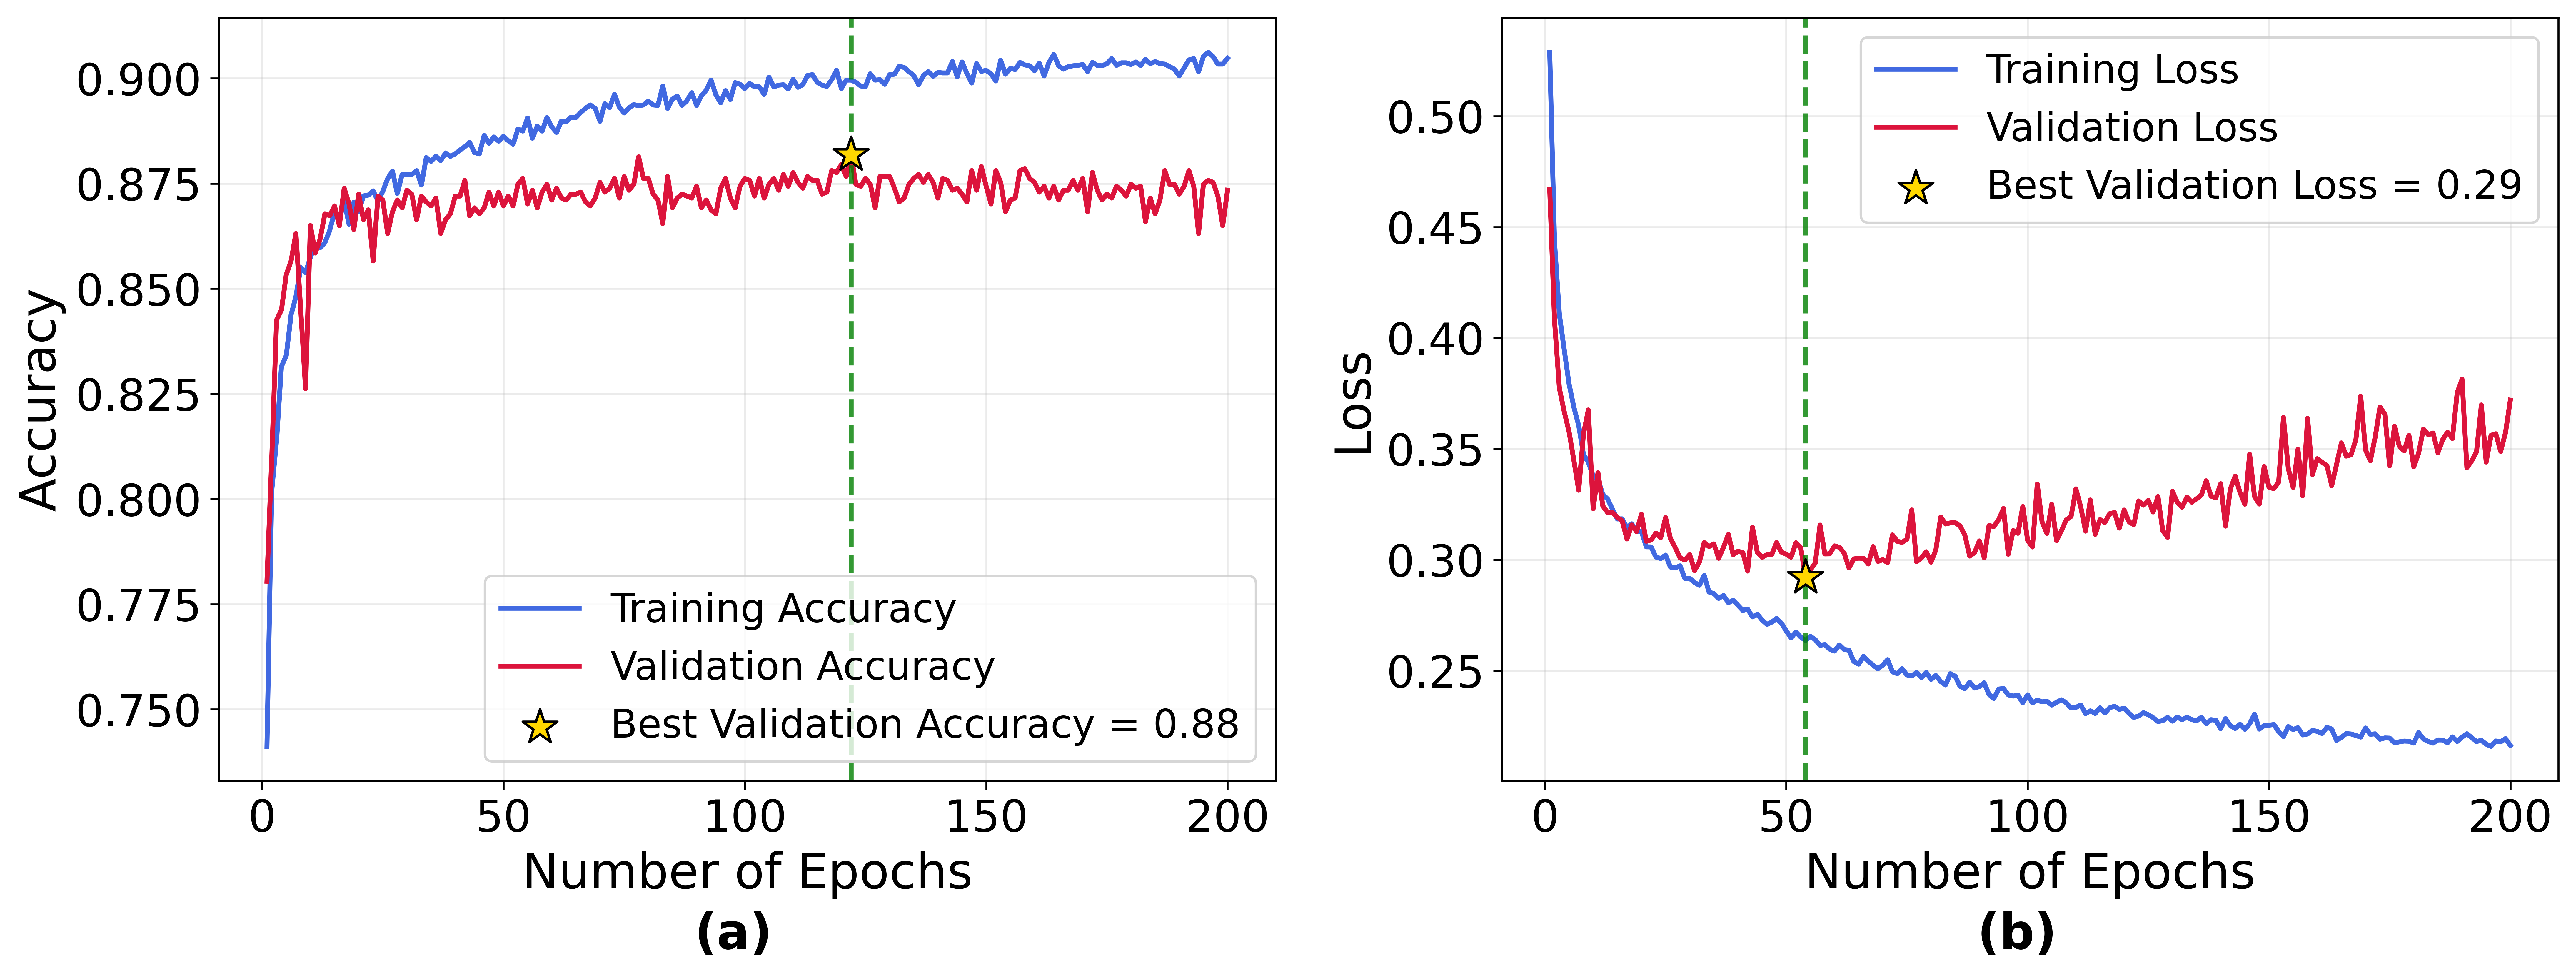

In [17]:
# ============================================================
# Font Settings
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# ============================================================
# Identify Best Epochs
# ============================================================

if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

best_acc_idx = df["val_accuracy"].idxmax()
best_acc_epoch = int(df.loc[best_acc_idx, "epoch"])
best_acc = float(df.loc[best_acc_idx, "val_accuracy"])

best_loss_idx = df["val_loss"].idxmin()
best_loss_epoch = int(df.loc[best_loss_idx, "epoch"])
best_loss = float(df.loc[best_loss_idx, "val_loss"])

# ============================================================
# Combined Learning Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# ============================================================
# Accuracy Plot
# ============================================================
ax1.plot(df["epoch"], df["accuracy"], linewidth=2,
         color="royalblue", label="Training Accuracy")

ax1.plot(df["epoch"], df["val_accuracy"], linewidth=2,
         color="crimson", label="Validation Accuracy")

ax1.axvline(best_acc_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax1.scatter(best_acc_epoch, best_acc,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Accuracy = {best_acc:.2f}")

ax1.set_xlabel("Number of Epochs")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True)

# Accuracy plot ticks
for tick, label in zip(ax1.get_xticks(), ax1.get_xticklabels()):
    if int(tick) == best_acc_epoch:
        label.set_fontweight("bold")
        label.set_color("green")

# ============================================================
# Loss Plot
# ============================================================
ax2.plot(df["epoch"], df["loss"], linewidth=2,
         color="royalblue", label="Training Loss")

ax2.plot(df["epoch"], df["val_loss"], linewidth=2,
         color="crimson", label="Validation Loss")

ax2.axvline(best_loss_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax2.scatter(best_loss_epoch, best_loss,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Loss = {best_loss:.2f}")

ax2.set_xlabel("Number of Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

# Loss plot ticks
for tick, label in zip(ax2.get_xticks(), ax2.get_xticklabels()):
    if int(tick) == best_loss_epoch:
        label.set_fontweight("bold")
        label.set_color("green")

# ============================================================
# Panel Labels
# ============================================================
ax1.text(0.45, -0.22, "(a)", transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

ax2.text(0.45, -0.22, "(b)", transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ============================================================
# Final layout
# ============================================================
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"),
            dpi=600, bbox_inches="tight")

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.pdf"),
            bbox_inches="tight")

plt.show()

### Classification Report

313/313 [==============================] - 4s 14ms/step

Evaluation Results: Train
Accuracy  : 0.907698
Precision : 0.902913
Recall    : 0.913410
F1-score  : 0.908131
ROC AUC   : 0.973668
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.912586  0.902000  0.907262      5000
         1.0   0.902913  0.913410  0.908131      4989

    accuracy                       0.907698      9989
   macro avg   0.907749  0.907705  0.907696      9989
weighted avg   0.907755  0.907698  0.907696      9989



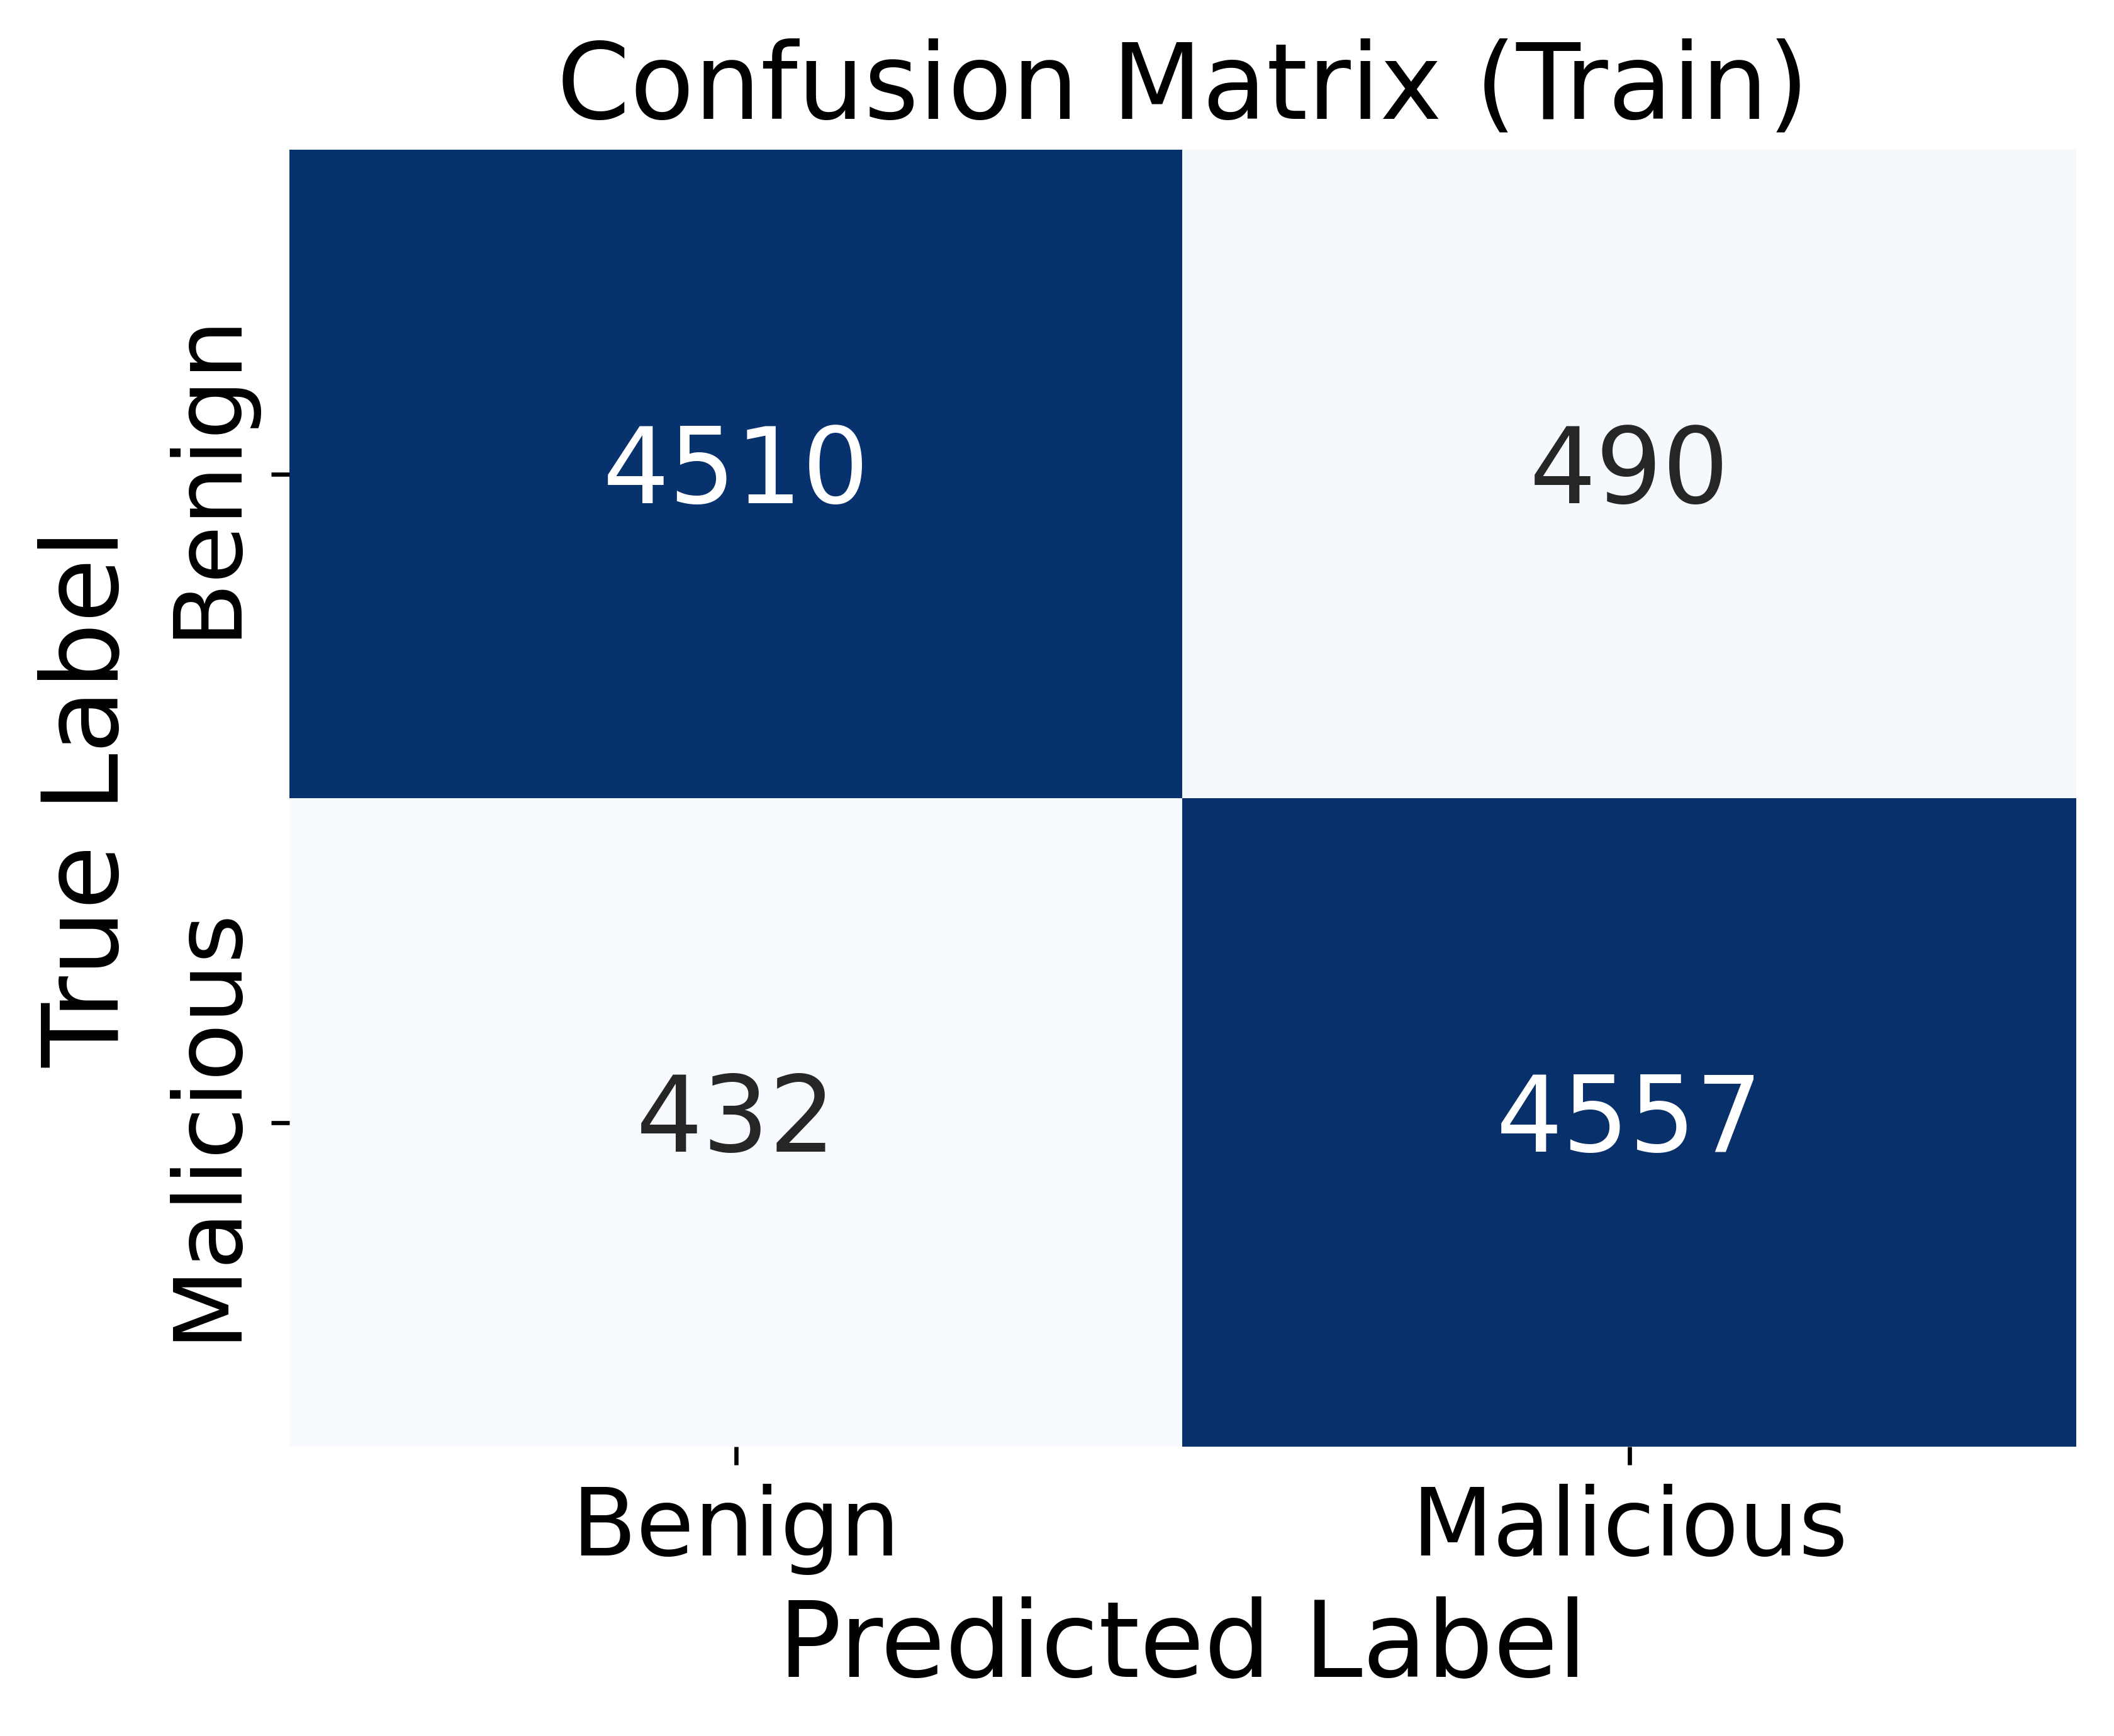

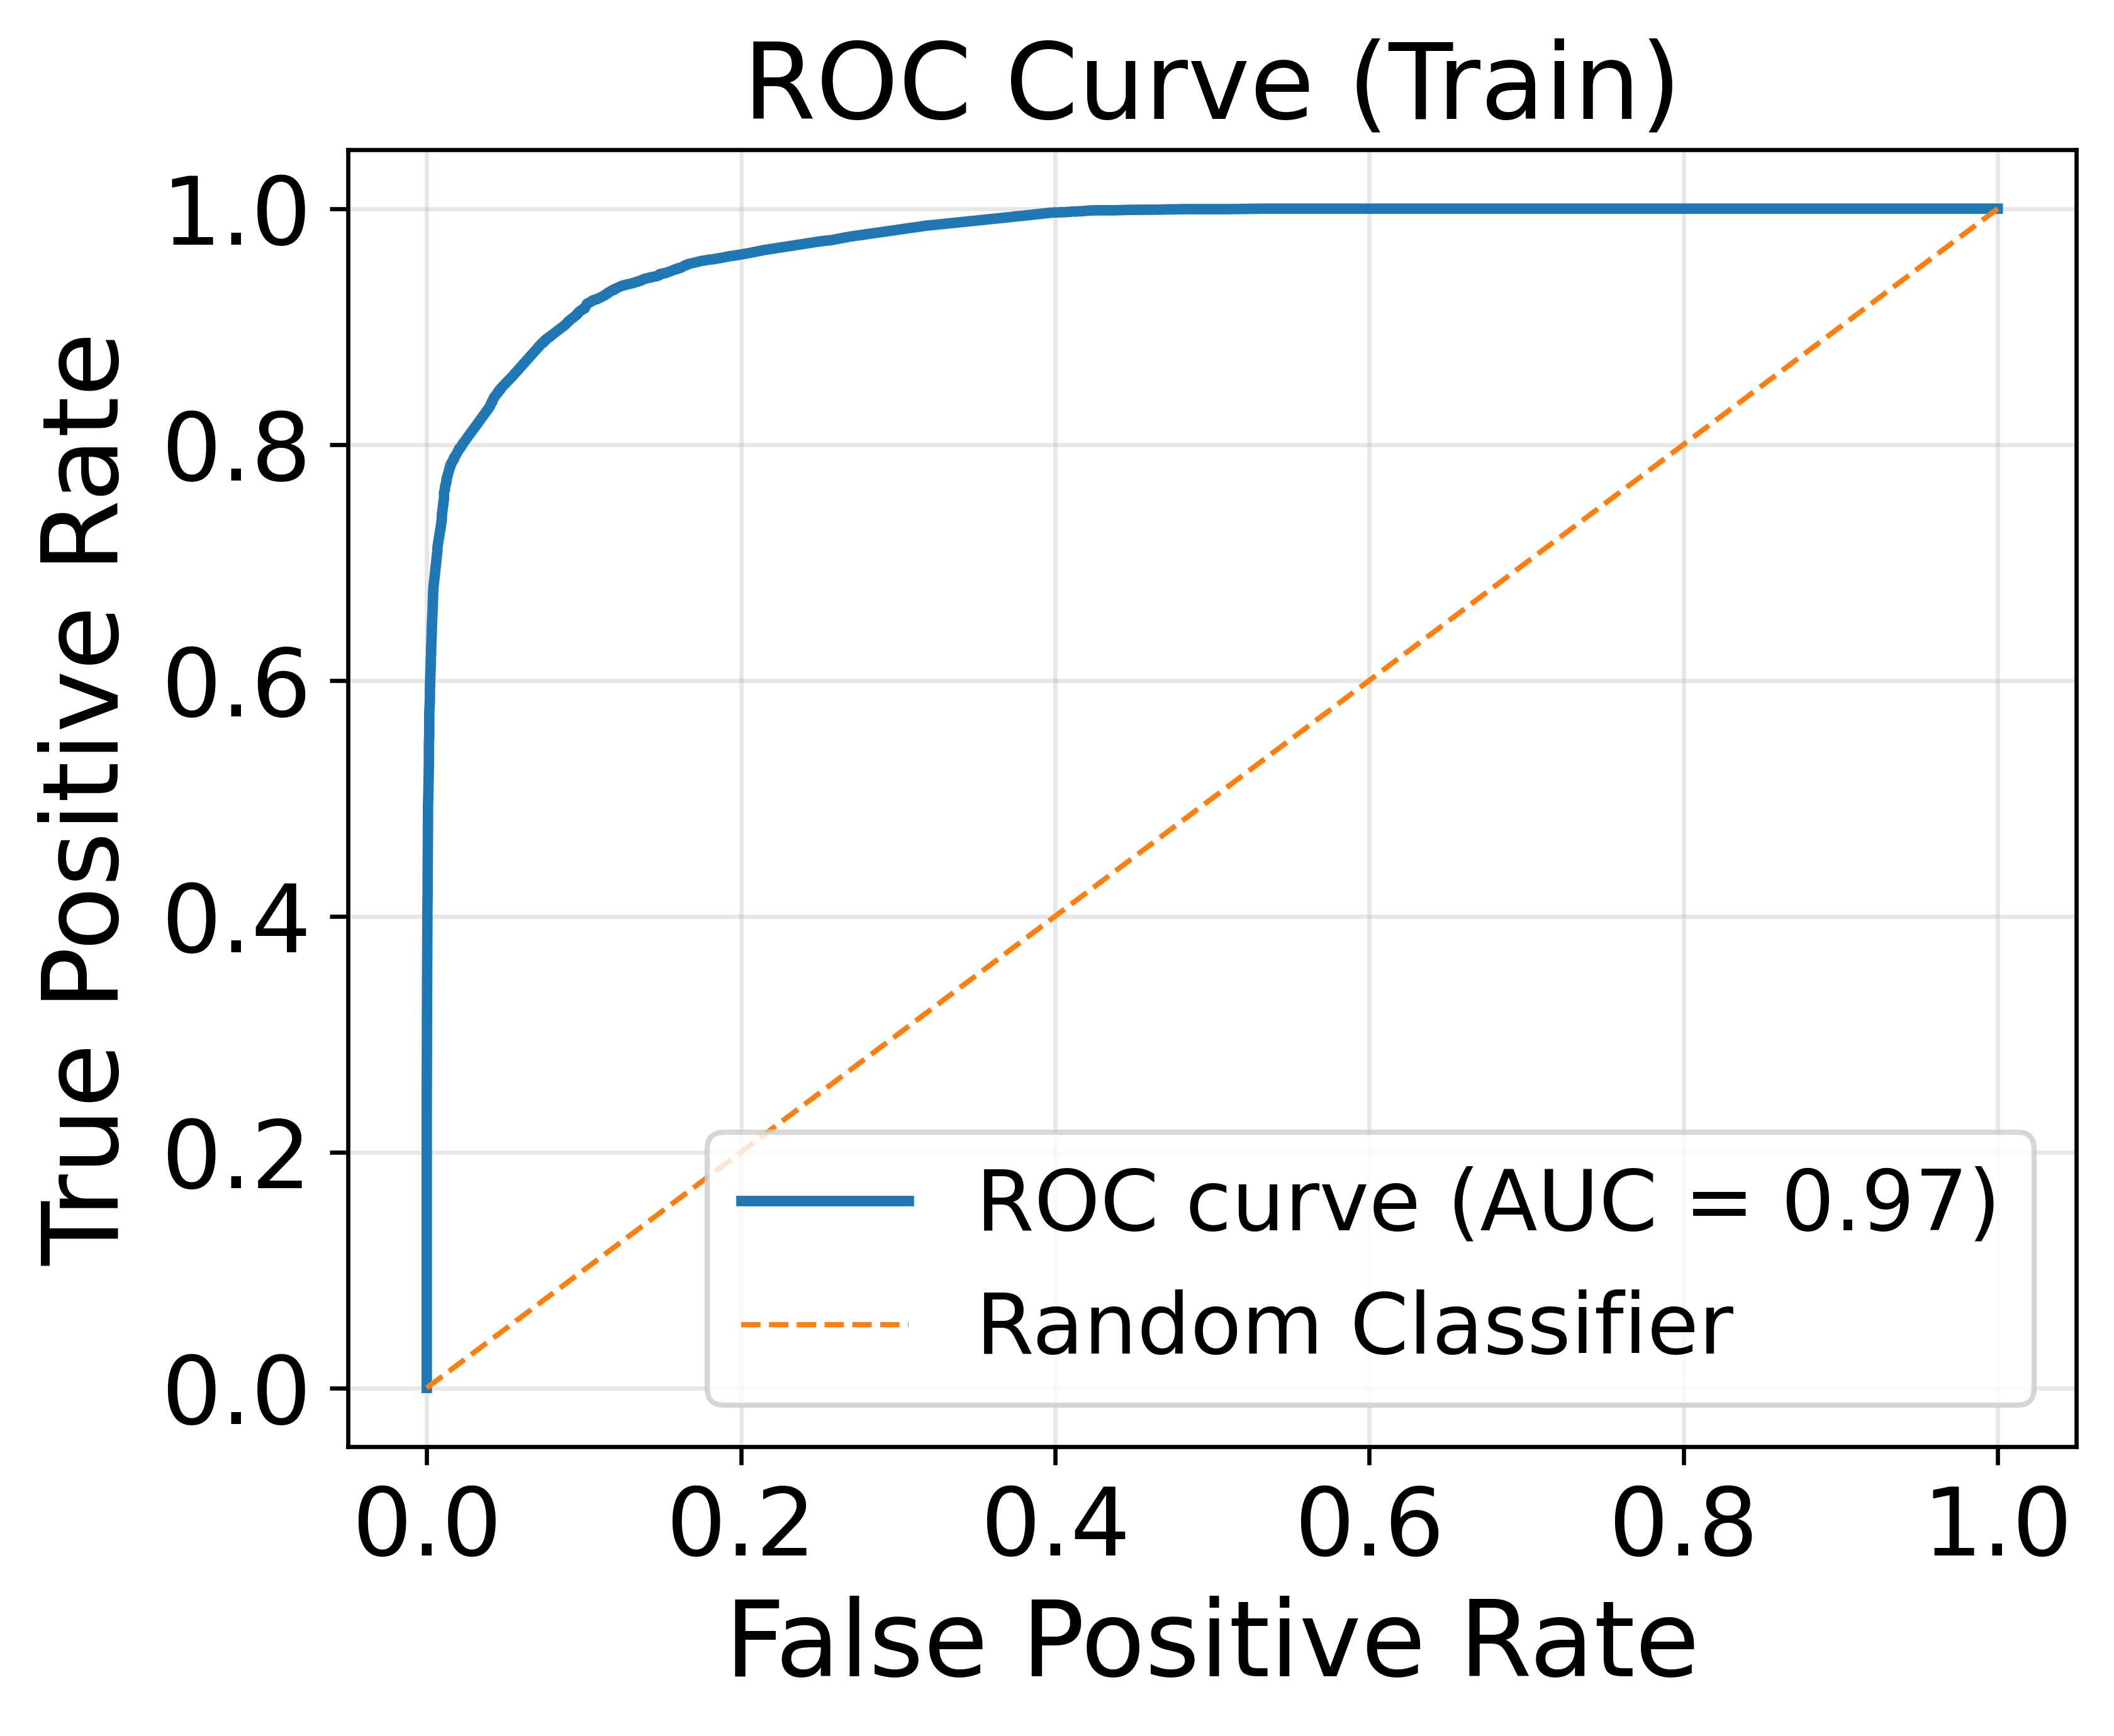

67/67 [==============================] - 1s 16ms/step

Evaluation Results: Validation
Accuracy  : 0.873424
Precision : 0.877841
Recall    : 0.867166
F1-score  : 0.872471
ROC AUC   : 0.939957
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.869124  0.879664  0.874363      1072
         1.0   0.877841  0.867166  0.872471      1069

    accuracy                       0.873424      2141
   macro avg   0.873483  0.873415  0.873417      2141
weighted avg   0.873477  0.873424  0.873418      2141



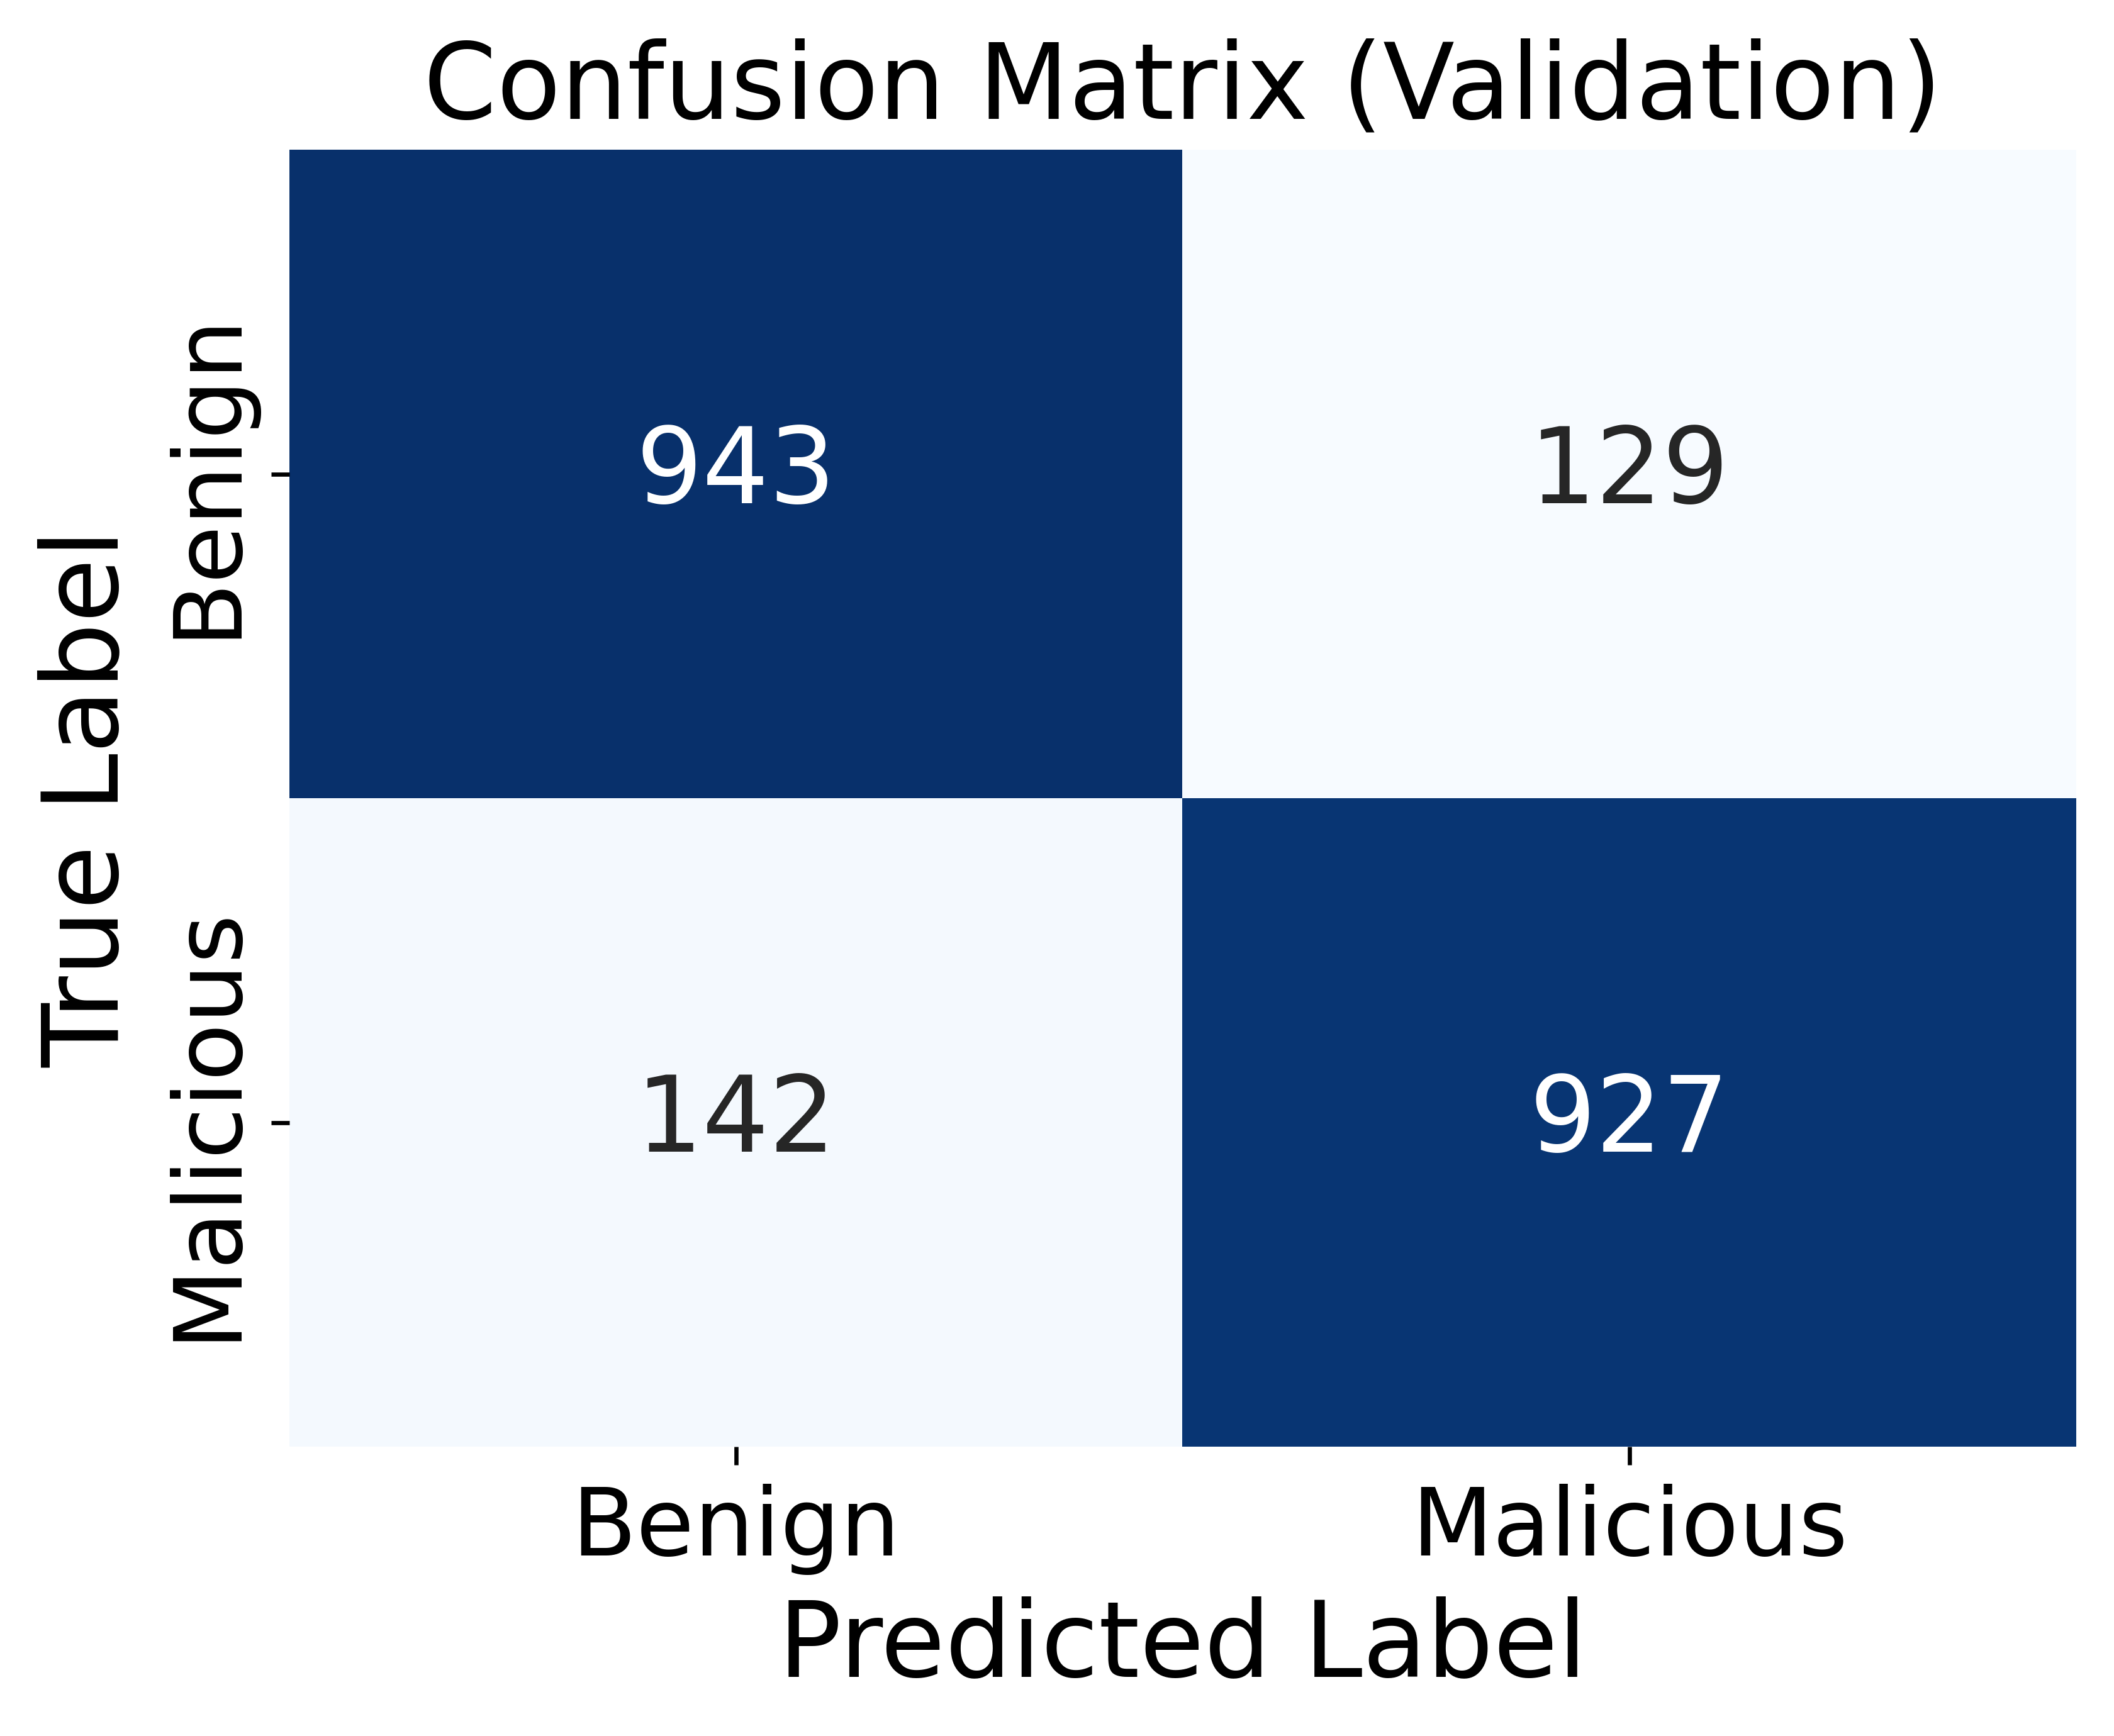

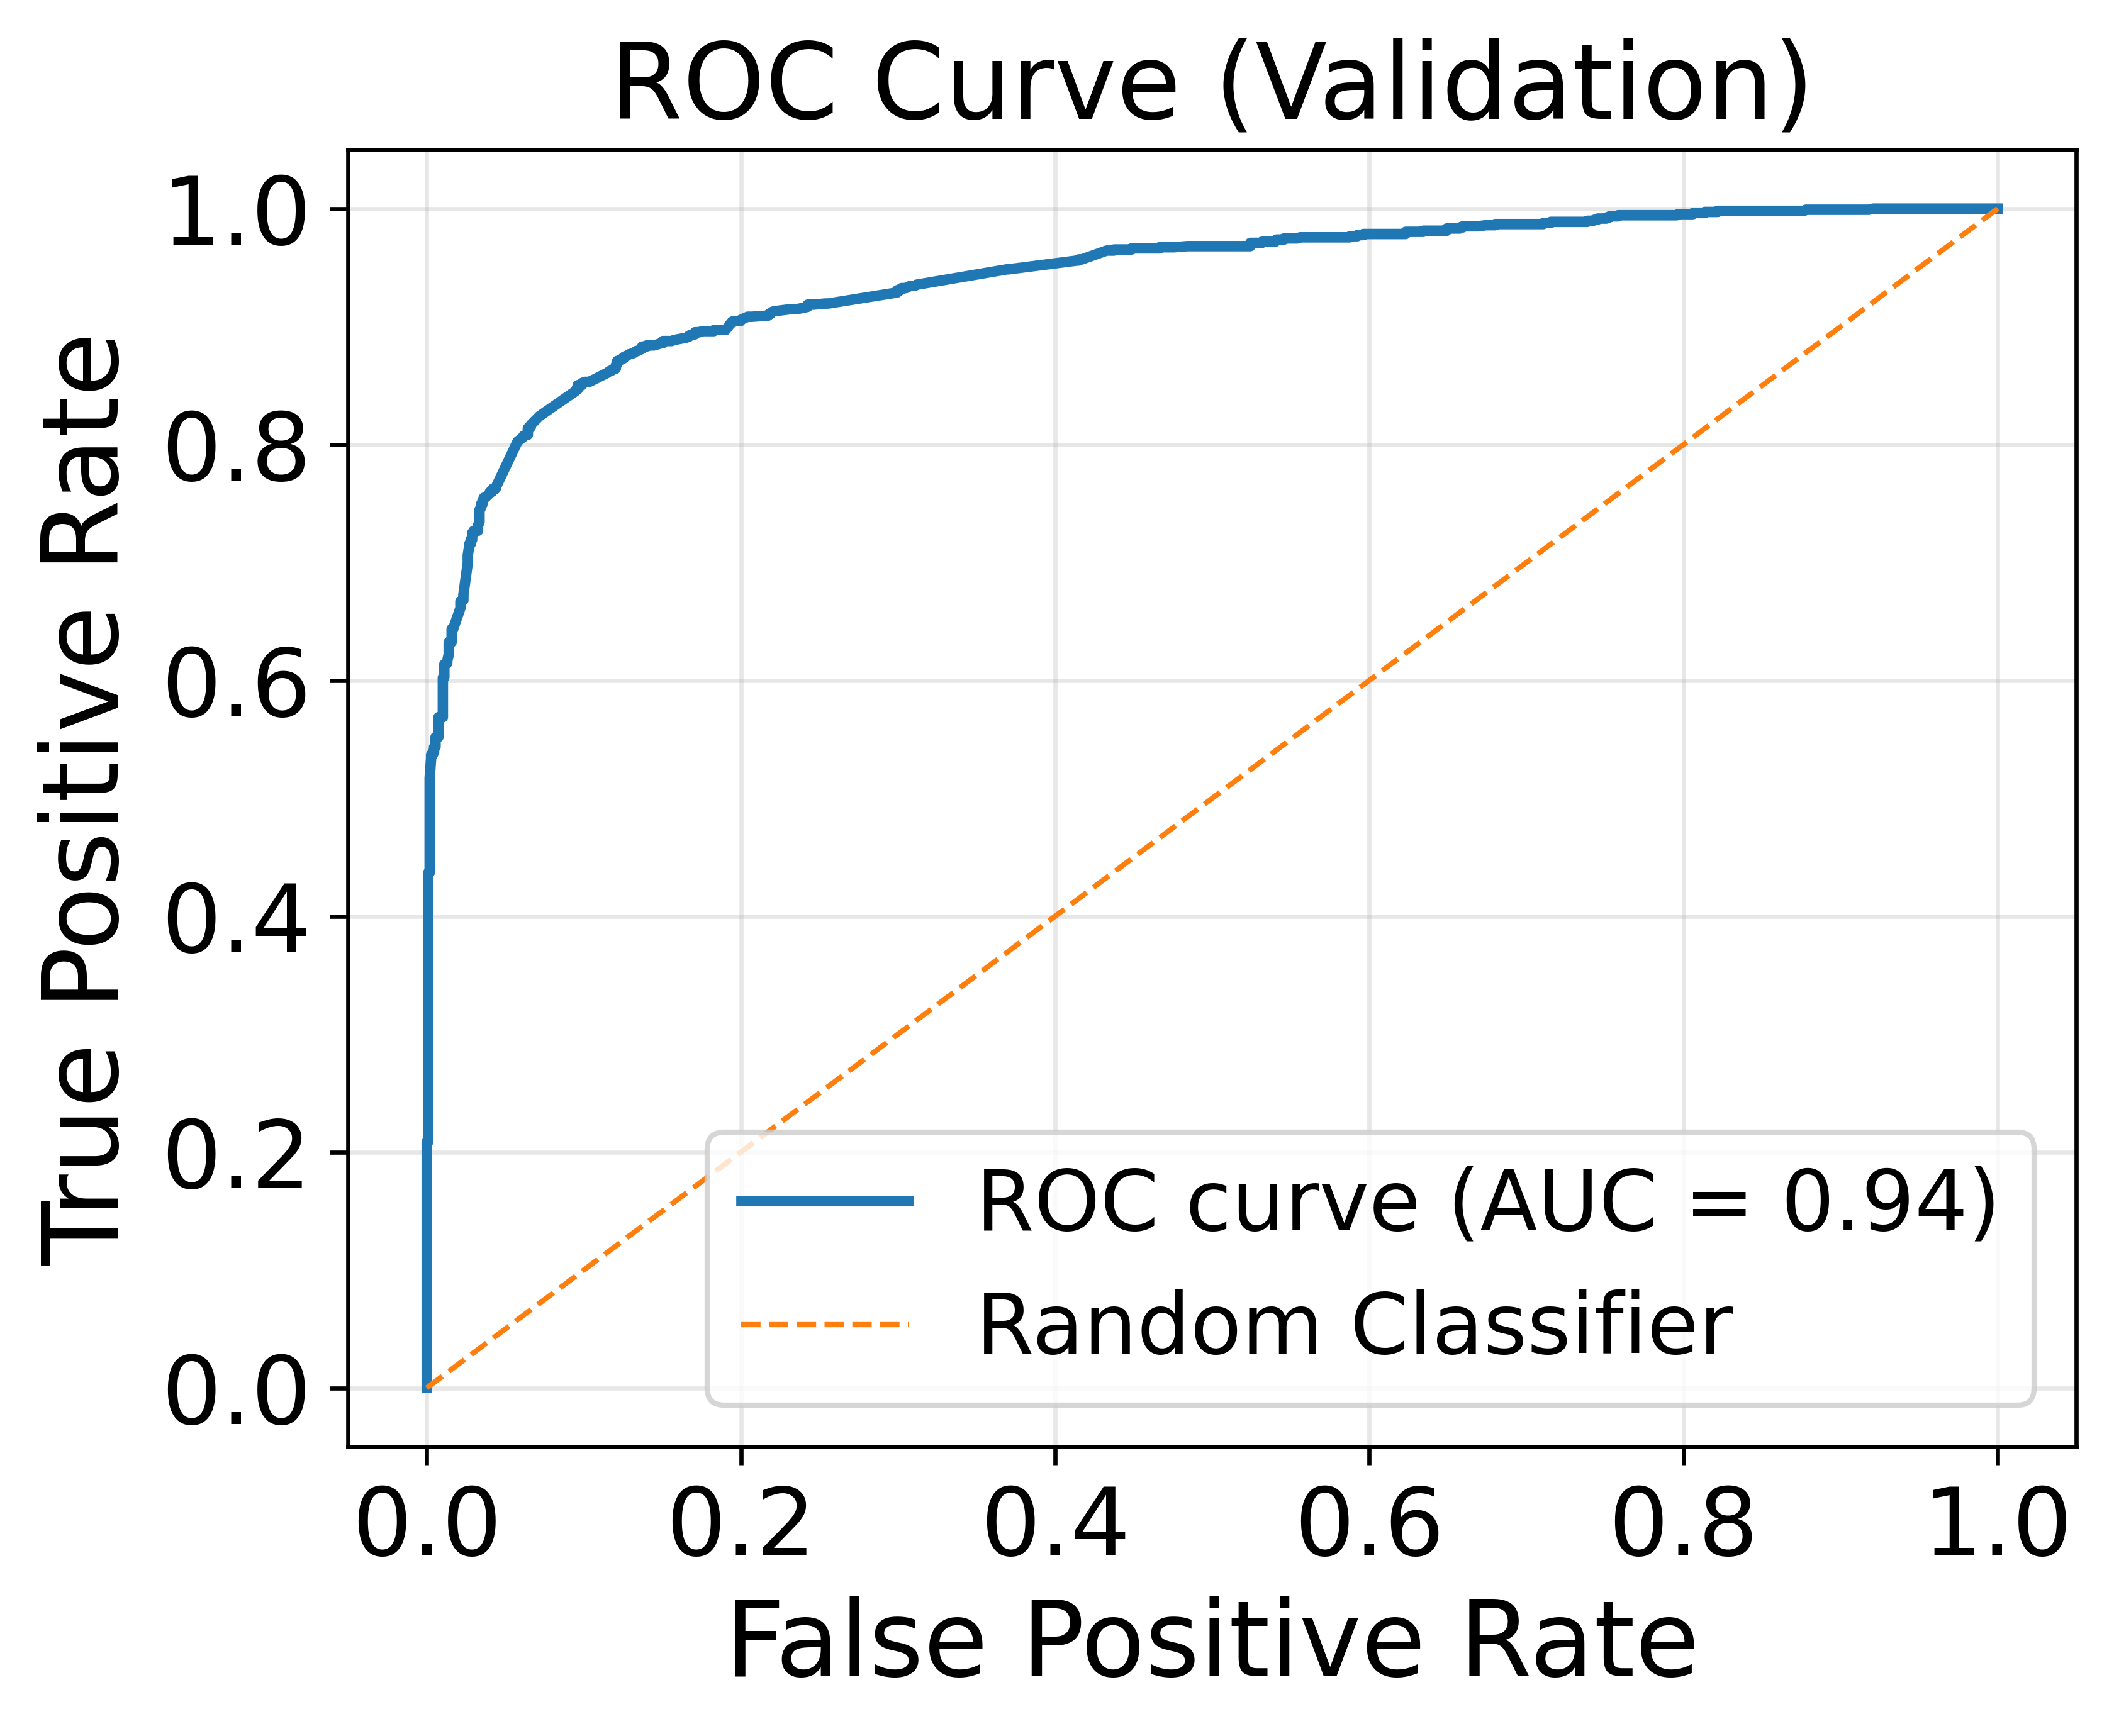

67/67 [==============================] - 1s 15ms/step

Evaluation Results: Test
Accuracy  : 0.886969
Precision : 0.886088
Recall    : 0.887746
F1-score  : 0.886916
ROC AUC   : 0.942011
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.887850  0.886194  0.887021      1072
         1.0   0.886088  0.887746  0.886916      1069

    accuracy                       0.886969      2141
   macro avg   0.886969  0.886970  0.886969      2141
weighted avg   0.886970  0.886969  0.886969      2141



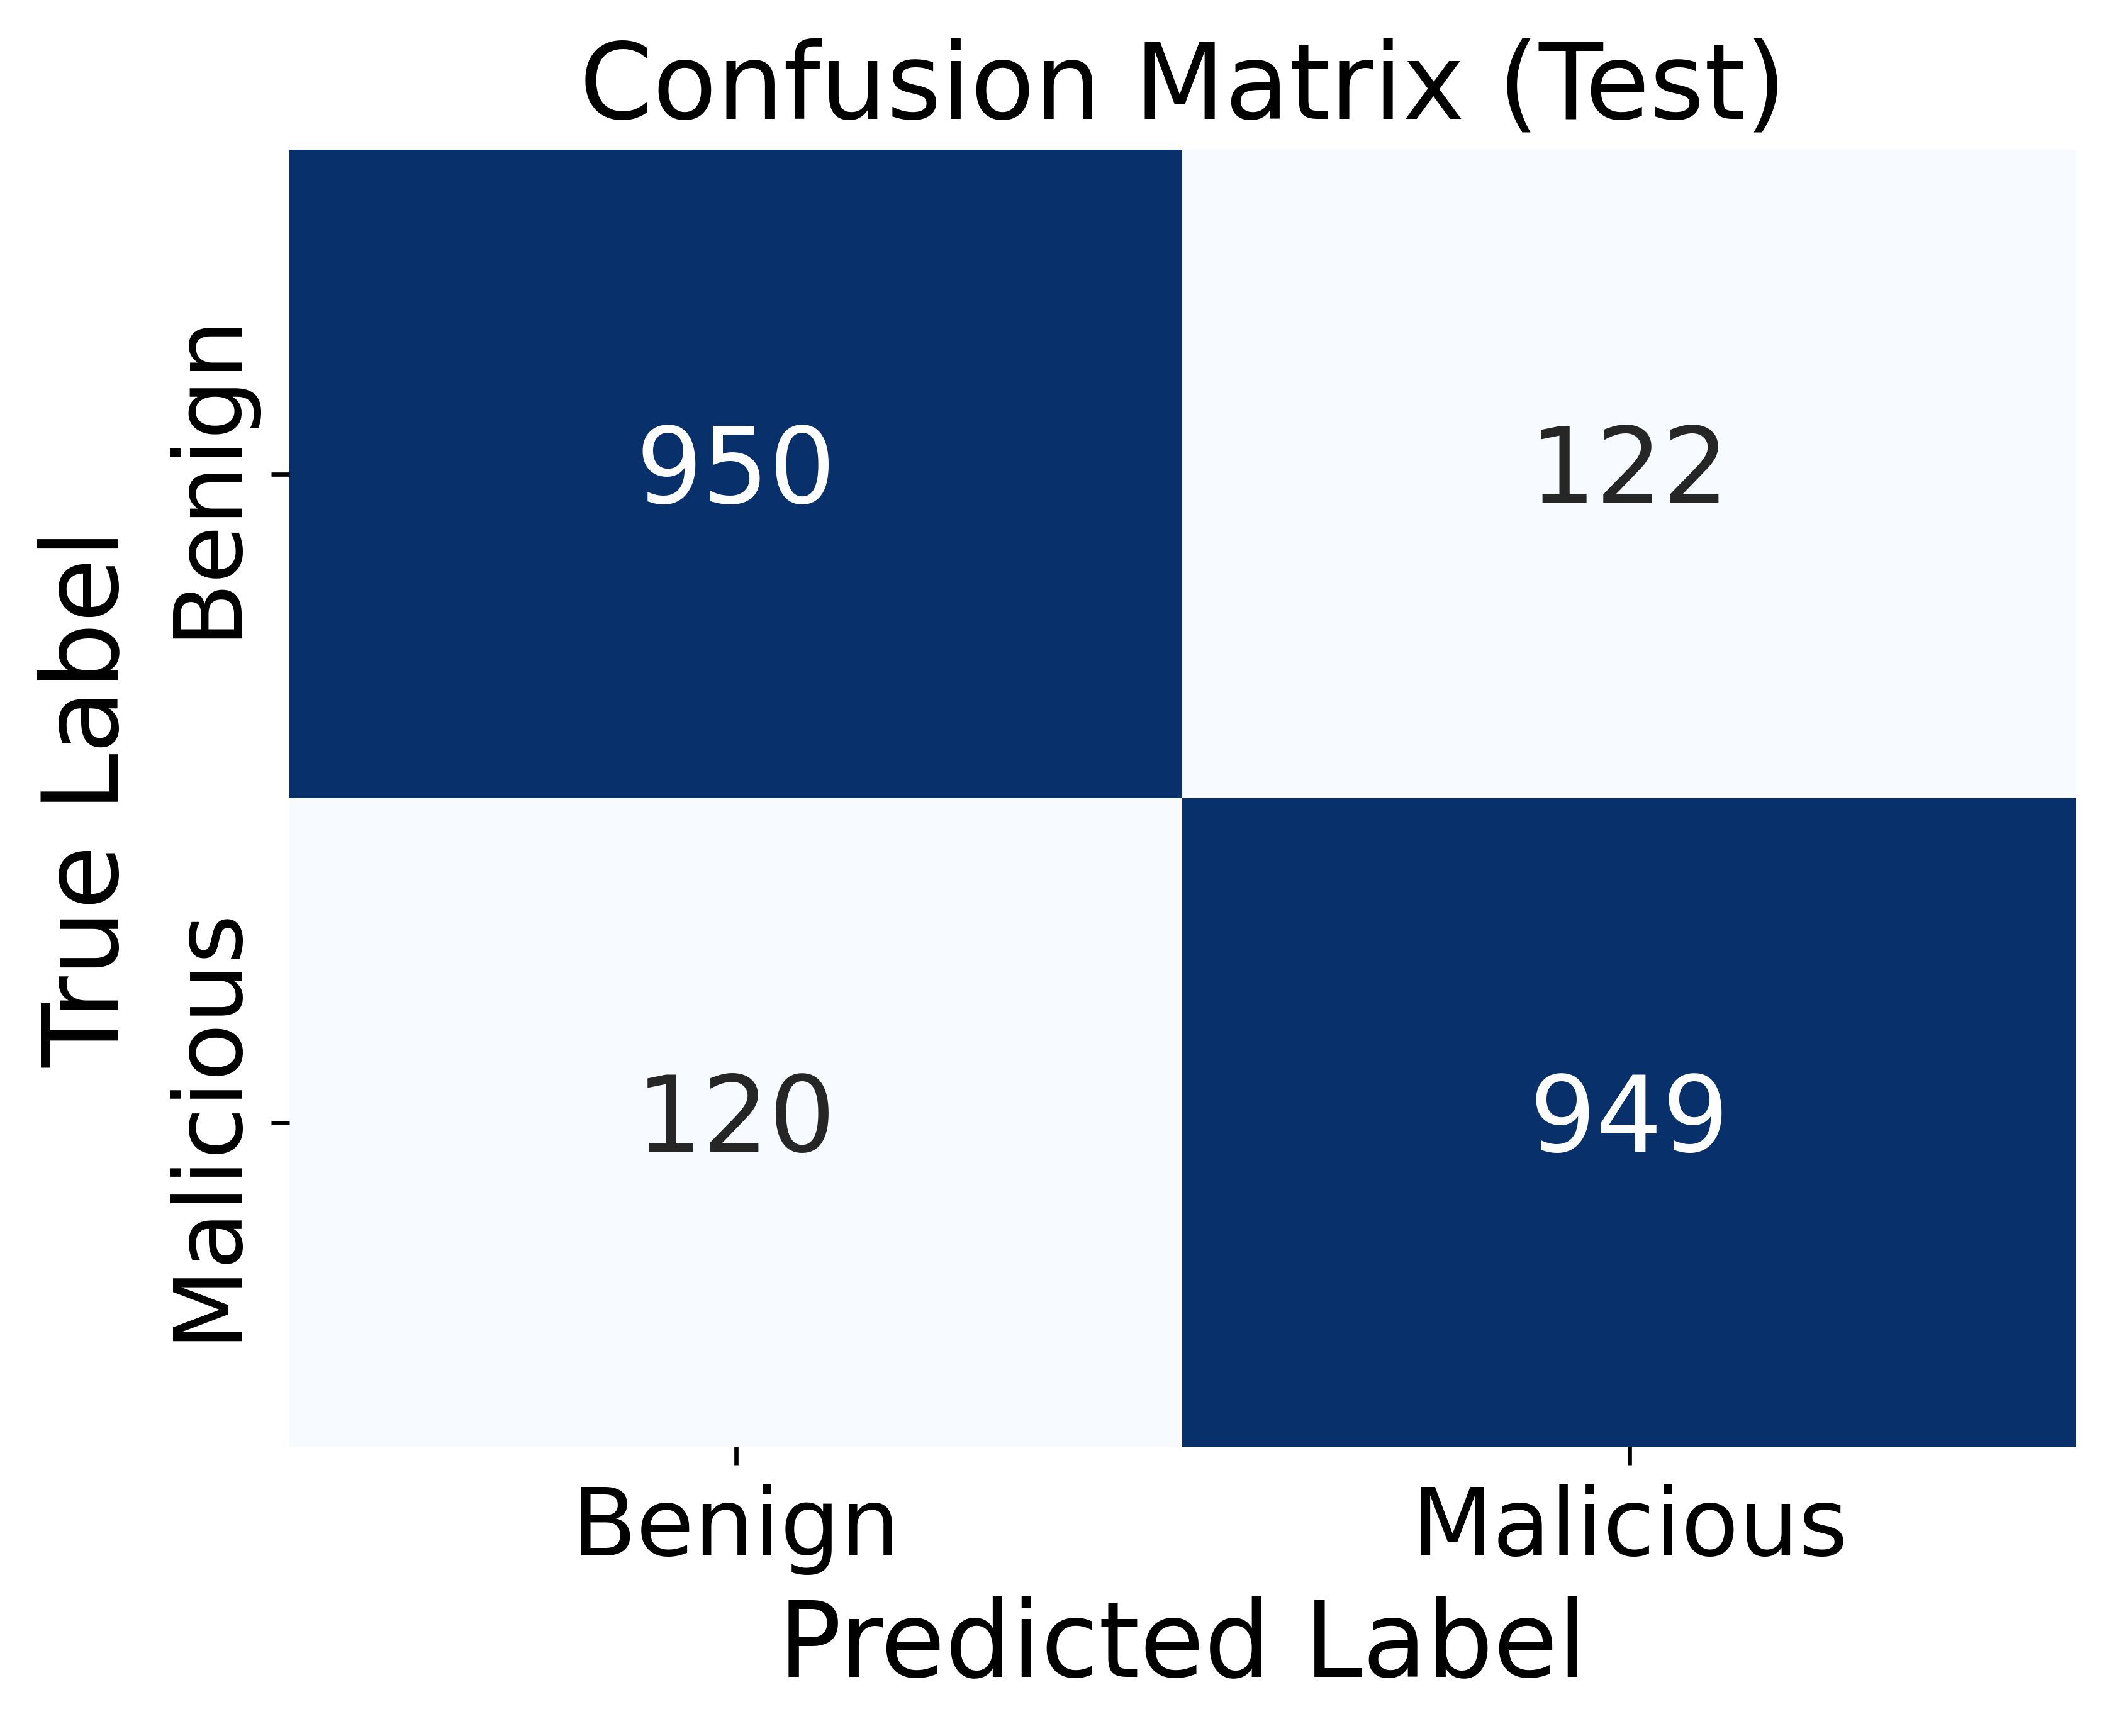

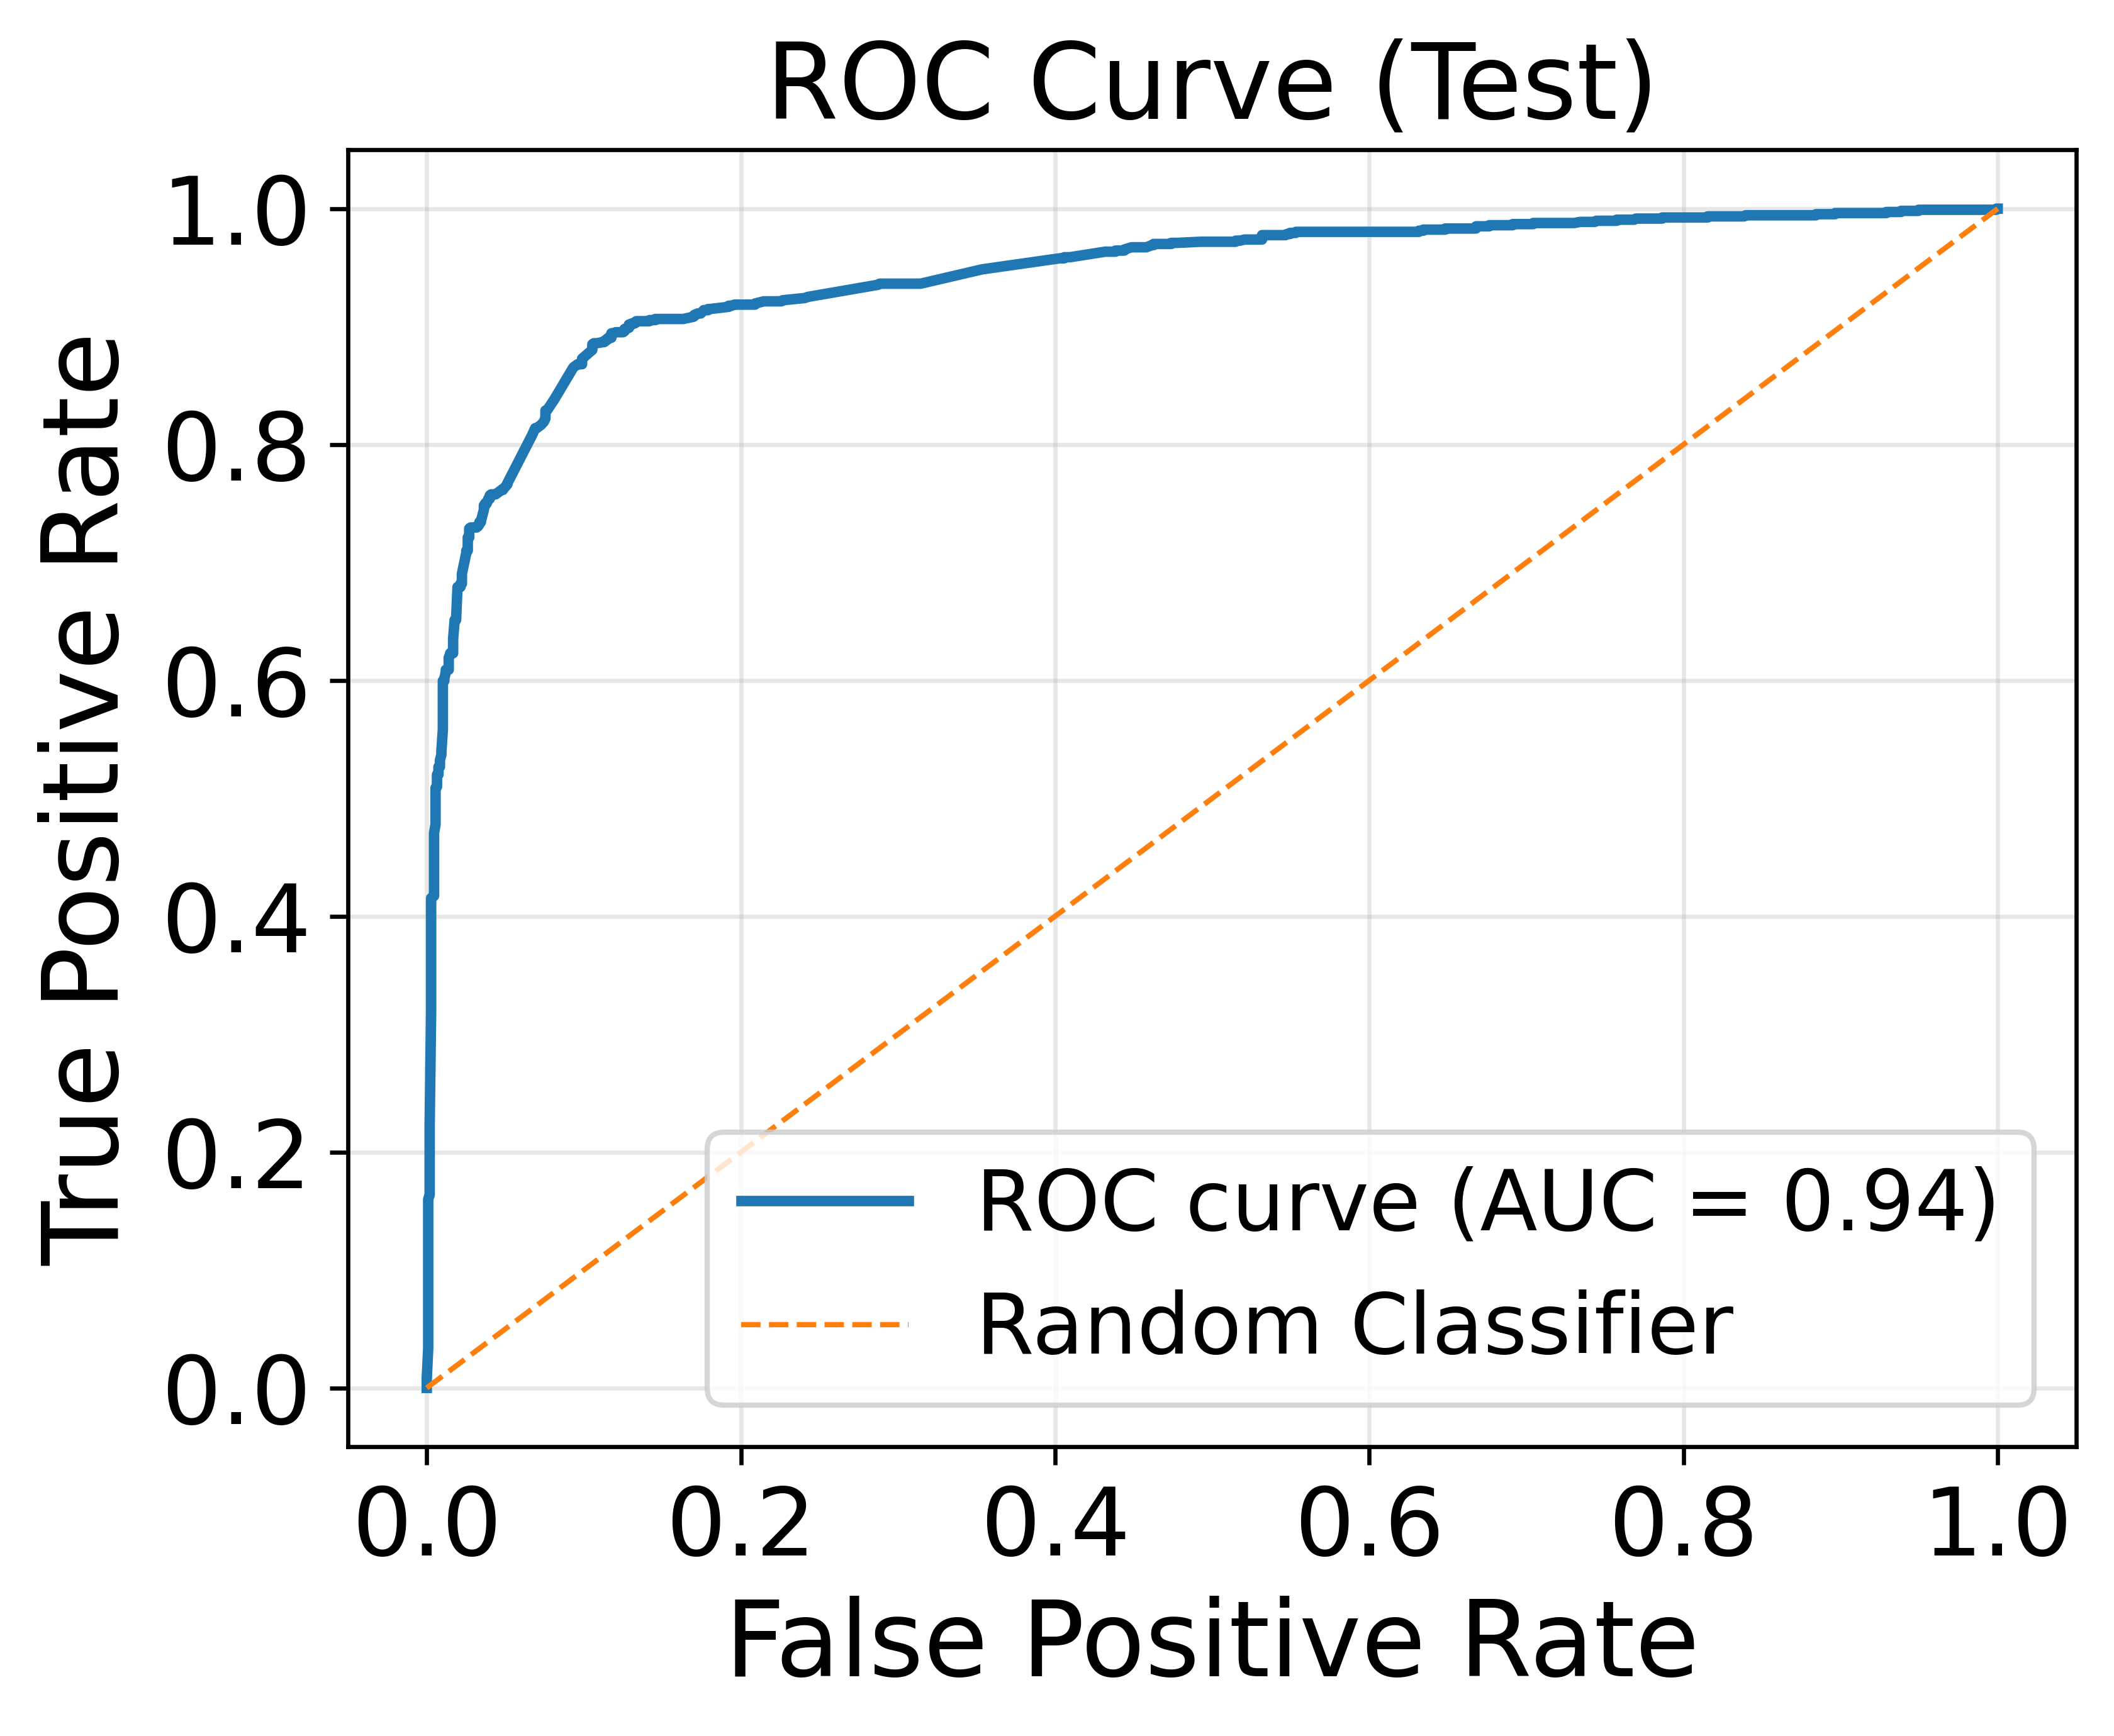

In [18]:
def evaluate_and_plot(model, X, y_true, dataset_name, output_dir=OUTPUT_DIR):
    """
    Evaluate the trained model on a given dataset and generate
    publication-quality confusion matrix and ROC curve figures.

    Parameters
    ----------
    model : keras.Model
        Trained classification model.
    encodings : dict or BatchEncoding
        Tokenized transformer inputs containing 'input_ids' and 'attention_mask'.
    y_true : array-like
        Ground-truth labels.
    dataset_name : str
        Name of the dataset split (e.g., 'Train', 'Validation', 'Test').
    output_dir : str, optional
        Directory where evaluation figures will be saved.

    Returns
    -------
    results : dict
        Dictionary containing predictions and evaluation metrics.
    """

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_prob = model.predict(X).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=6)

    # --------------------------------------------------------
    # Print evaluation summary
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"Evaluation Results: {dataset_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.6f}")
    print(f"Precision : {prec:.6f}")
    print(f"Recall    : {rec:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC AUC   : {roc_auc:.6f}")
    print("-" * 70)
    print("Classification Report:")
    print(report)

    # --------------------------------------------------------
    # Plot and save confusion matrix
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Malicious"],
        yticklabels=["Benign", "Malicious"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.tight_layout()

    cm_png = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.png")
    cm_pdf = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.pdf")
    plt.savefig(cm_png, dpi=600, bbox_inches="tight")
    plt.savefig(cm_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Plot and save ROC curve
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({dataset_name})")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_png = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.png")
    roc_pdf = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.pdf")
    plt.savefig(roc_png, dpi=600, bbox_inches="tight")
    plt.savefig(roc_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Return results for further analysis/reporting
    # --------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y_true),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix_png": cm_png,
        "confusion_matrix_pdf": cm_pdf,
        "roc_curve_png": roc_png,
        "roc_curve_pdf": roc_pdf
    }

    return results


# ============================================================
# Evaluate on Training, Validation, and Test Sets
# ============================================================

train_results = evaluate_and_plot(model, X_train_pad, y_train, "Train")
val_results   = evaluate_and_plot(model, X_val_pad, y_val, "Validation")
test_results  = evaluate_and_plot(model, X_test_pad, y_test, "Test")

### Save All Results

In [19]:
# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Dataset": train_results["dataset"],
        "Accuracy": train_results["accuracy"],
        "Precision": train_results["precision"],
        "Recall": train_results["recall"],
        "F1-score": train_results["f1_score"],
        "ROC AUC": train_results["roc_auc"]
    },
    {
        "Dataset": val_results["dataset"],
        "Accuracy": val_results["accuracy"],
        "Precision": val_results["precision"],
        "Recall": val_results["recall"],
        "F1-score": val_results["f1_score"],
        "ROC AUC": val_results["roc_auc"]
    },
    {
        "Dataset": test_results["dataset"],
        "Accuracy": test_results["accuracy"],
        "Precision": test_results["precision"],
        "Recall": test_results["recall"],
        "F1-score": test_results["f1_score"],
        "ROC AUC": test_results["roc_auc"]
    }
])

# ------------------------------------------------------------
# Define save paths
# ------------------------------------------------------------
csv_path  = os.path.join(OUTPUT_DIR, "evaluation_summary.csv")
xlsx_path = os.path.join(OUTPUT_DIR, "evaluation_summary.xlsx")

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------
summary_df.to_csv(csv_path, index=False)
summary_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------
print("=" * 60)
print("Evaluation summary saved successfully:")
print(f"CSV  : {csv_path}")
print(f"Excel: {xlsx_path}")
print("=" * 60)

# Display table
summary_df

Evaluation summary saved successfully:
CSV  : Evaluation_Outputs_Pattern_Corr_Pre_Attention_RNN\evaluation_summary.csv
Excel: Evaluation_Outputs_Pattern_Corr_Pre_Attention_RNN\evaluation_summary.xlsx


,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Train,0.907698,0.902913,0.913410,0.908131,0.973668
1,Validation,0.873424,0.877841,0.867166,0.872471,0.939957
2,Test,0.886969,0.886088,0.887746,0.886916,0.942011


### Clear Final Backend Session

In [20]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()